**comparison between the results of three datasets**


In [4]:
from google.colab import files

uploaded = files.upload()

Saving results_dataset1.csv to results_dataset1.csv


In [5]:
from google.colab import files

uploaded = files.upload()

Saving results_dataset2.csv to results_dataset2.csv


In [6]:
from google.colab import files

uploaded = files.upload()

Saving results_dataset3.csv to results_dataset3.csv


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

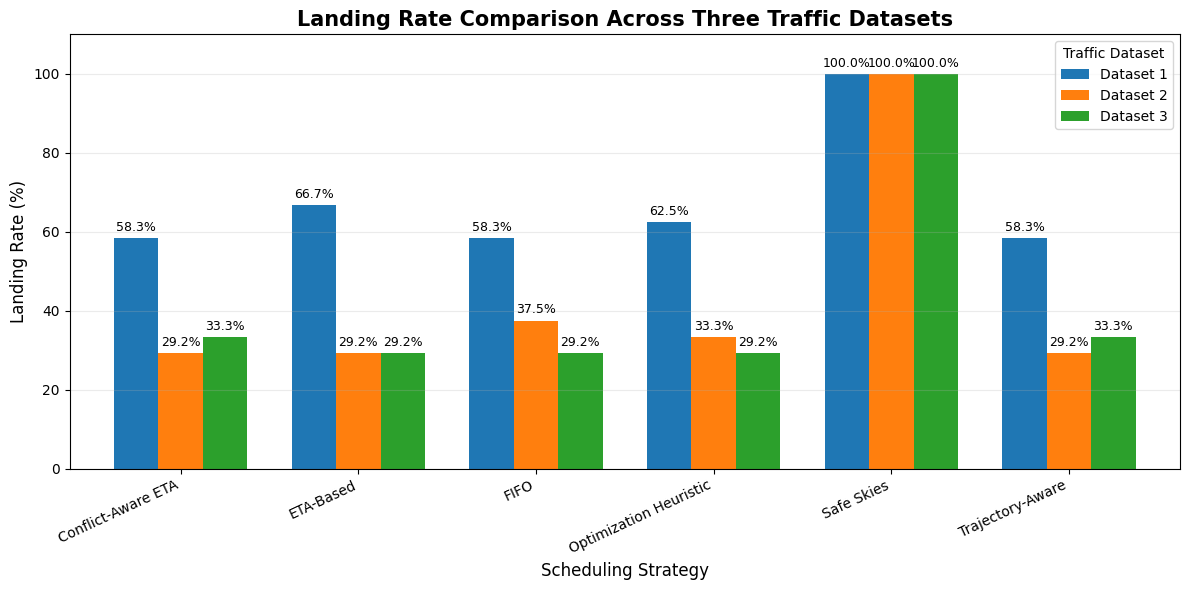

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
d1 = pd.read_csv("results_dataset1.csv")
d2 = pd.read_csv("results_dataset2.csv")
d3 = pd.read_csv("results_dataset3.csv")

# Add dataset names
d1["Dataset"] = "Dataset 1"
d2["Dataset"] = "Dataset 2"
d3["Dataset"] = "Dataset 3"

# Combine datasets
df = pd.concat([d1, d2, d3], ignore_index=True)

# Calculate total number of aircraft
df["Aircraft Count"] = df["Landed"] + df["Airborne"]

# Calculate Landing Rate
df["Landing Rate (%)"] = (
    df["Landed"] / 24 * 100
)


# Function for creating comparison graphs
def plot_metric(metric, title, ylabel):

    pivot = df.pivot(
        index="Strategy",
        columns="Dataset",
        values=metric
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(11, 6)
    )

    plt.title(title)
    plt.xlabel("Strategy")
    plt.ylabel(ylabel)

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.legend(title="Dataset")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# GRAPH 1: Landing Rate Comparison
# ============================================================

pivot = df.pivot(
    index="Strategy",
    columns="Dataset",
    values="Landing Rate (%)"
)

ax = pivot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.75
)

# Titles and labels
plt.title(
    "Landing Rate Comparison Across Three Traffic Datasets",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Scheduling Strategy", fontsize=12)
plt.ylabel("Landing Rate (%)", fontsize=12)

# Y axis
plt.ylim(0, 110)
plt.yticks(range(0, 101, 20))

# Strategy labels
plt.xticks(
    rotation=25,
    ha="right",
    fontsize=10
)

# Legend
plt.legend(
    title="Traffic Dataset",
    loc="upper right"
)

# Light horizontal grid
plt.grid(
    axis="y",
    alpha=0.25
)

# ------------------------------------------------------------
# Add exact percentage above every bar
# ------------------------------------------------------------

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() > 0 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()



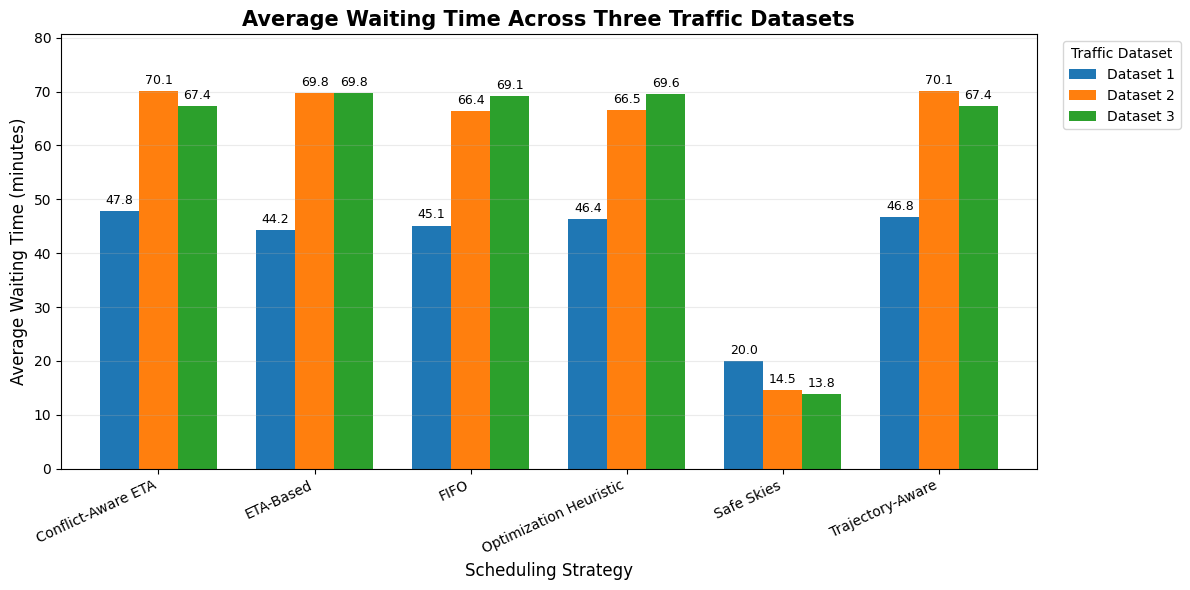

In [12]:

# GRAPH 2: Average Waiting Time - All Aircraft

pivot = df.pivot(
    index="Strategy",
    columns="Dataset",
    values="Average Wait - All Aircraft (min)"
)

ax = pivot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.75
)

# Title and labels
plt.title(
    "Average Waiting Time Across Three Traffic Datasets",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Scheduling Strategy", fontsize=12)
plt.ylabel("Average Waiting Time (minutes)", fontsize=12)

# X labels
plt.xticks(
    rotation=25,
    ha="right",
    fontsize=10
)

# Give space for values above bars
max_value = pivot.max().max()
plt.ylim(0, max_value * 1.15)

# Legend - move it outside the graph
plt.legend(
    title="Traffic Dataset",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Grid
plt.grid(
    axis="y",
    alpha=0.25
)

# Add exact values above bars
for container in ax.containers:

    labels = [
        f"{bar.get_height():.1f}"
        if bar.get_height() > 0 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

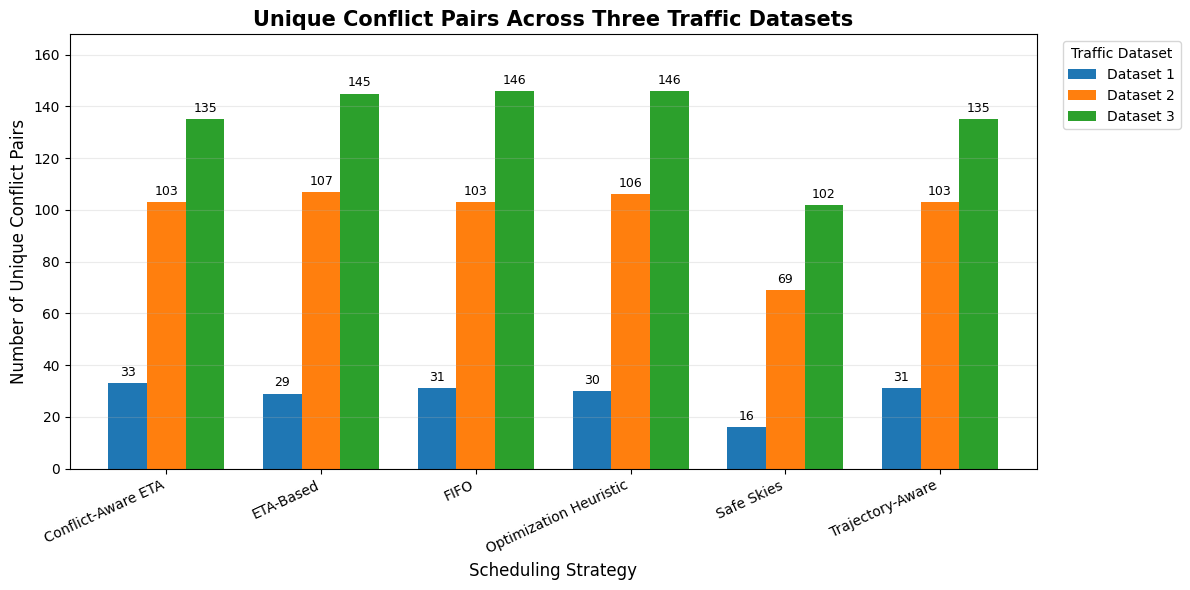

In [16]:
# ============================================================
# GRAPH 3 Unique Conflict Pairs
# ============================================================

pivot = df.pivot(
    index="Strategy",
    columns="Dataset",
    values="Unique Conflict Pairs"
)

ax = pivot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.75
)

# Title and labels
plt.title(
    "Unique Conflict Pairs Across Three Traffic Datasets",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Scheduling Strategy", fontsize=12)
plt.ylabel("Number of Unique Conflict Pairs", fontsize=12)

# X-axis labels
plt.xticks(
    rotation=25,
    ha="right",
    fontsize=10
)

# Add space above highest value
max_value = pivot.max().max()
plt.ylim(0, max_value * 1.15)

# Legend outside
plt.legend(
    title="Traffic Dataset",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Horizontal grid
plt.grid(
    axis="y",
    alpha=0.25
)

# Add exact values above each bar
for container in ax.containers:
    labels = [
        f"{bar.get_height():.0f}"
        if bar.get_height() > 0 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()